In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# EDA(Exploratory Data Analysis)

In [ ]:
df = pd.read_csv("/content/Messy_Employee_dataset.csv")
#first 5 rows/records by default or use df.tail() for last rows
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [ ]:
#get the num of rows and cols
df.shape

(1020, 12)

In [ ]:
#datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


In [ ]:
#finds count, mean, min, max, SD, quartiles
#.T is transpose
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,809.0,3.248455e+01,5.656860e+00,2.500000e+01,2.500000e+01,3.000000e+01,4.000000e+01,40.00
Salary,996.0,8.515506e+04,1.987373e+04,5.004732e+04,6.839249e+04,8.554787e+04,1.009740e+05,119971.65
Phone,1020.0,-4.942253e+09,2.817326e+09,-9.994973e+09,-7.341992e+09,-4.943997e+09,-2.520391e+09,-3896086.00


In [ ]:
#list of columns
df.columns.tolist()

['Employee_ID',
 'First_Name',
 'Last_Name',
 'Age',
 'Department_Region',
 'Status',
 'Join_Date',
 'Salary',
 'Email',
 'Phone',
 'Performance_Score',
 'Remote_Work']

In [ ]:
#getting the number of null val per columns
df.isnull().sum()

,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,211
Department_Region,0
Status,0
Join_Date,0
Salary,24
Email,0
Phone,0


In [ ]:
#get the number of duplicates per columns
df.duplicated().sum()

np.int64(0)

In [ ]:
#get the categorical columns and numerical columns
cat_cols = [col for col in df.columns if df[col].dtype == "object"]
num_cols = [col for col in df.columns if df[col].dtype != "object"]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['Employee_ID', 'First_Name', 'Last_Name', 'Department_Region', 'Status', 'Join_Date', 'Email', 'Performance_Score']
Numerical columns: ['Age', 'Salary', 'Phone', 'Remote_Work']


In [ ]:
#num of unique values per column
df[cat_cols].nunique()

,0
Employee_ID,1020
First_Name,8
Last_Name,8
Department_Region,36
Status,3
Join_Date,760
Email,64
Performance_Score,4


In [ ]:
#getting the % of num values per column
round((df.isnull().sum()/df.shape[0])*100,2)

,0
Employee_ID,0.00
First_Name,0.00
Last_Name,0.00
Age,20.69
Department_Region,0.00
Status,0.00
Join_Date,0.00
Salary,2.35
Email,0.00
Phone,0.00


# Data cleaning

In [ ]:
# df.drop(columns="Status")   ----------or add an array of cols in the param(columns) to drop the columns
# df.dropna(subset="Status", inplace=True)  ----------dropping rows having null values and inplace makes the change permanent
df["Age"] = df['Age'].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())
df.isnull().sum()

,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,0
Department_Region,0
Status,0
Join_Date,0
Salary,0
Email,0
Phone,0


# EDA with plots and charts

In [ ]:
df["Age"] = df["Age"].astype("int64")
df["Age"]

,Age
0,25
1,32
2,32
3,25
4,25
...,...
1015,30
1016,30
1017,40
1018,30


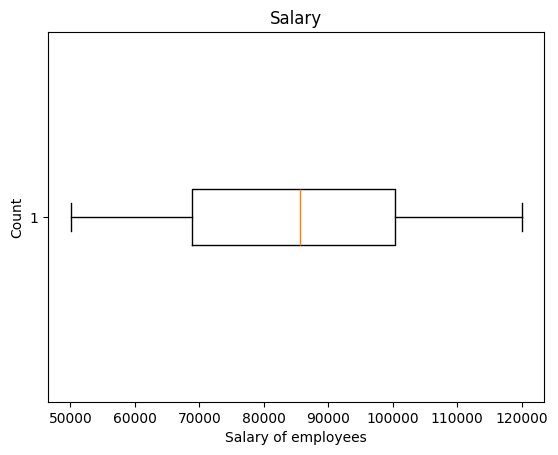

In [ ]:
# box plot for outliers
plt.boxplot(df["Salary"], vert=False)
plt.title("Salary")
plt.xlabel("Salary of employees")
plt.ylabel("Count")
plt.show()

# Conc: No outliers

In [ ]:
# getting outlier boundaries
# mean +/- 2 * std ---------- lower and upper bounds
mean = df["Salary"].mean()
std = df["Salary"].std()

lower = mean - 2 * std
upper = mean + 2 * std

df2 = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]
df2

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,32,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,32,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1015,EMP2015,David,Miller,30,HR-California,Active,8/19/2023,85547.87,david.miller@example.com,-3546212759,Good,True
1016,EMP2016,David,Johnson,30,Cloud Tech-Texas,Inactive,11/7/2021,100215.06,david.johnson@example.com,-2508261122,Good,True
1017,EMP2017,Charlie,Williams,40,Finance-New York,Active,10/4/2023,114587.11,charlie.williams@example.com,-1261632487,Average,False
1018,EMP2018,Alice,Garcia,30,HR-Florida,Inactive,12/16/2024,71318.79,alice.garcia@example.com,-8995729892,Good,True


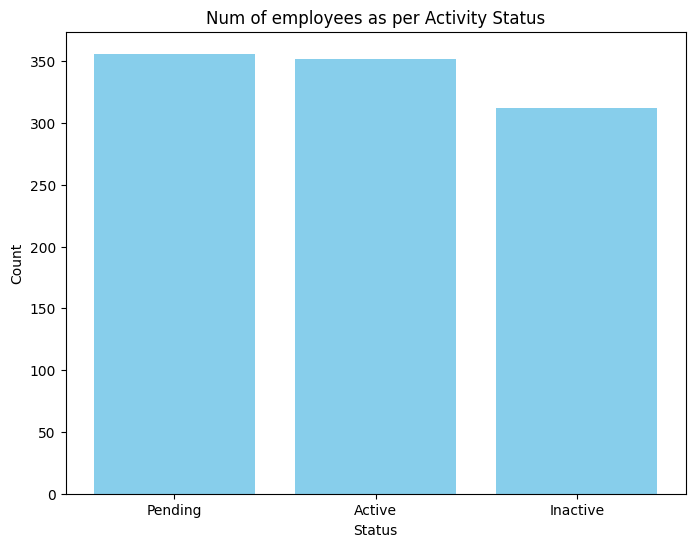

In [ ]:
#Bar chart of employees as per status

status_count = df["Status"].value_counts()

plt.figure(figsize=(8,6))
plt.bar(status_count.index, status_count, color="skyblue")
plt.title("Num of employees as per Activity Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

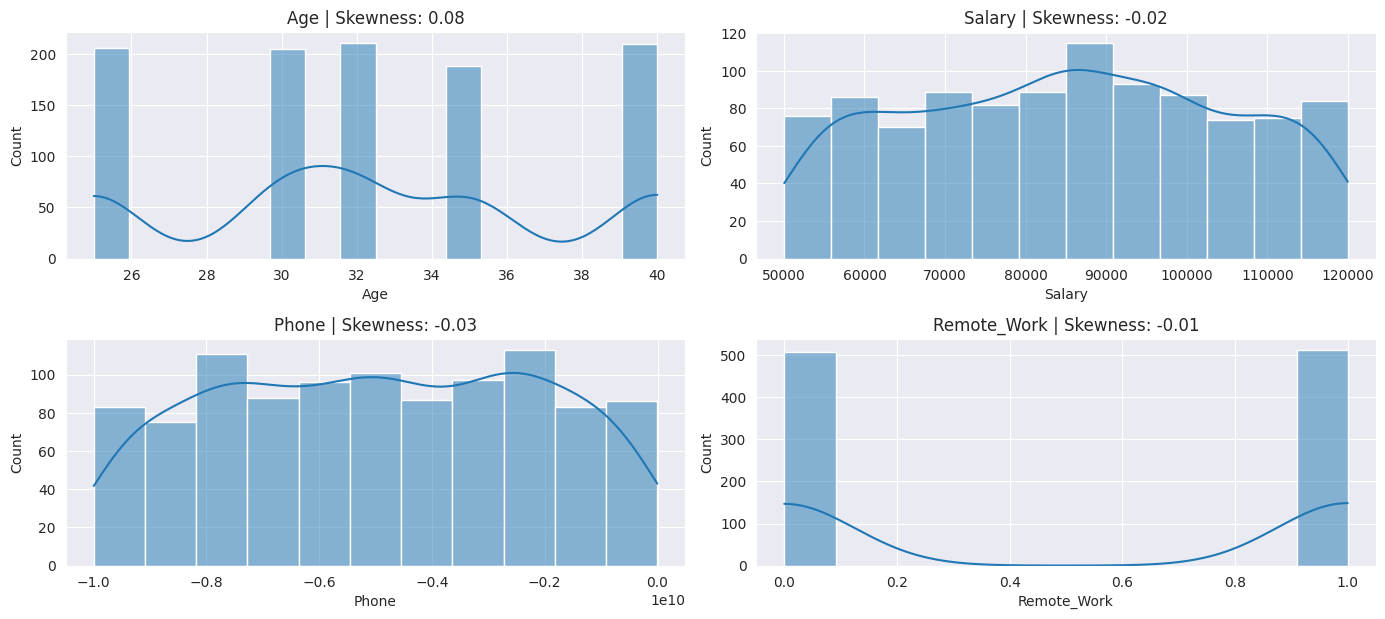

In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize=(14, len(num_cols*3)))
for (i, feature) in enumerate(num_cols, 1):
  plt.subplot(len(num_cols), 2, i)
  sns.histplot(df[feature], kde=True)
  plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")
plt.tight_layout()
plt.show()